# PubMed API Demo


## Setup

In [158]:
from pprint import pprint

import requests

BASE_URL = "http://analyticsdashboardalbbalancer-1386294349.us-east-2.elb.amazonaws.com:8000"
# BASE_URL = "http://localhost:8080"

def print_response(response):
    print(f"Status Code: {response.status_code}")
    if response.status_code == 200:
        try:
            data = response.json()
            print("Response:")
            pprint(data)
        except:
            print("Response (text):", response.text)
    else:
        print("Error:", response.text)

## 1. Insert Articles by Keyword

In [ ]:
url = f"{BASE_URL}/pubmed/articles"
headers = {
    "Content-Type": "application/json",
    "user": "deeptha"
}
data = {
    # "keyword": "Global Alliance for Genomics and Health Your DNA, Your Say",
    # "keyword": "Global Alliance for Genomics and Health Beacon",
    # "keyword": "Global Alliance for Genomics and Health",
    # "keyword": "GA4GH",
    # "keyword": "Global Alliance for Genomics and Health Regulatory & Ethics Work Stream",
    # "keyword": "Global Alliance for Genomics and Health Diversity in Datasets",
    # "keyword": "Global Alliance for Genomics and Health Framework for responsible sharing of genomic and health-related data",
    # "keyword": "Global Alliance for Genomics and Health Health Policy on Clinically Actionable Genomic Research Results",
    "pubmed_db": "pubmed"
}

print("=== INSERT ARTICLES BY KEYWORD ===")
print(f"POST {url}")
print(f"Headers: {headers}")
print(f"Data: {data}")
print()

response = requests.post(url, json=data, headers=headers)
print_response(response)

=== INSERT ARTICLES BY KEYWORD ===
POST http://analyticsdashboardalbbalancer-1386294349.us-east-2.elb.amazonaws.com:8000/pubmed/articles
Headers: {'Content-Type': 'application/json', 'user': 'deeptha'}
Data: {'keyword': 'Global Alliance for Genomics and Health Health Policy on Clinically Actionable Genomic Research Results', 'pubmed_db': 'pubmed'}

Status Code: 200
Response:
{'created': 0, 'processed': 1, 'skipped': 0, 'updated': 1}


## 2. Get Articles by Keyword (Basic Search)

In [121]:
keyword = "GA4GH"
url = f"{BASE_URL}/pubmed/articles/{keyword}"

print("=== GET ARTICLES BY KEYWORD (Basic) ===")
print(f"GET {url}")
print()

response = requests.get(url)
print_response(response)

=== GET ARTICLES BY KEYWORD (Basic) ===
GET http://localhost:8080/pubmed/articles/GA4GH

Status Code: 200
Response:
[{'abstract': 'The Beacon v2 specification, established by the Global Alliance '
              'for Genomics and Health (GA4GH), consists of a standardized '
              'framework and data models for genomic and phenotypic data '
              'discovery. By enabling secure, federated data sharing, it '
              'fosters interoperability across genomic resources. Progenetix, '
              'a Beacon v2 reference implementation, exemplifies its potential '
              'for large-scale genomic data integration, offering open access '
              'to genomic mutation data across diverse cancer types.',
  'authors': [{'article_id': 1,
               'article_type': 'Article',
               'contact': None,
               'created_at': '2025-10-04T21:48:51.395538',
               'created_by': 'demo_user',
               'deleted_at': None,
               'delete

## 3. Get Articles by Keyword and Start Date

In [49]:
keyword = "Global Alliance for Genomics and Health"
start_date = "2020-09-11"

url = f"{BASE_URL}/pubmed/articles/{keyword}"
params = {
    "start_date": start_date
}

print("=== GET ARTICLES BY KEYWORD AND DATE ===")
print(f"GET {url}")
print(f"Params: {params}")
print()

response = requests.get(url, params=params)
print_response(response)

=== GET ARTICLES BY KEYWORD AND DATE ===
GET http://localhost:8080/pubmed/articles/Global Alliance for Genomics and Health
Params: {'start_date': '2020-09-11'}

Status Code: 200
Response:
[{'abstract': 'Genomic data-sharing beacon protocol, developed by the Global '
              'Alliance for Genomics and Health, offers a privacy-preserving '
              'mechanism for querying genomic datasets while restricting '
              'direct data access. Despite their design, beacons remain '
              'vulnerable to privacy attacks. This study introduces a novel '
              'privacy vulnerability of the protocol: one can reconstruct '
              'large portions of the genomes of all beacon participants by '
              'only using the summary statistics reported by the protocol.',
  'authors': [{'article_id': 1,
               'article_type': 'Article',
               'contact': None,
               'created_at': '2025-09-16T02:42:36.788843',
               'created_by': 'de

## 4. Get Articles by Keyword and Date Range

In [50]:
keyword = "Global Alliance for Genomics and Health"
start_date = "2020-09-11"
end_date = "2022-09-11"

url = f"{BASE_URL}/pubmed/articles/{keyword}"
params = {
    "start_date": start_date,
    "end_date": end_date
}

print("=== GET ARTICLES BY KEYWORD AND START DATE ===")
print(f"GET {url}")
print(f"Params: {params}")
print()

response = requests.get(url, params=params)
print_response(response)

=== GET ARTICLES BY KEYWORD AND START DATE ===
GET http://localhost:8080/pubmed/articles/Global Alliance for Genomics and Health
Params: {'start_date': '2020-09-11', 'end_date': '2022-09-11'}

Status Code: 200
Response:
[{'abstract': 'The increased demand for efficient computation in data analysis '
              'encourages researchers in biomedical science to use workflow '
              'systems. Workflow systems, or so-called workflow languages, are '
              'used for the description and execution of a set of data '
              'analysis steps. Workflow systems increase the productivity of '
              'researchers, specifically in fields that use high-throughput '
              'DNA sequencing applications, where scalable computation is '
              'required. As systems have improved the portability of data '
              'analysis workflows, research communities are able to share '
              'workflows to reduce the cost of building ordinary analysis '
      

## 5. Get Articles by Keyword and Status


In [51]:
keyword = "Global Alliance for Genomics and Health"
status = "Preprint"

url = f"{BASE_URL}/pubmed/articles/{keyword}"
params = {
    "status": status
}

print("=== GET ARTICLES BY KEYWORD AND STATUS ===")
print(f"GET {url}")
print(f"Params: {params}")
print()

response = requests.get(url, params=params)
print_response(response)

=== GET ARTICLES BY KEYWORD AND STATUS ===
GET http://localhost:8080/pubmed/articles/Global Alliance for Genomics and Health
Params: {'status': 'Preprint'}

Status Code: 404
Error: {"detail":"No articles found for criteria"}


## 6. Get Beacon Articles by Keyword 

In [88]:
keyword = "Global Alliance for Genomics and Health Your DNA, Your Say"
url = f"{BASE_URL}/pubmed/articles/{keyword}"

print("=== GET ARTICLES BY KEYWORD (Basic) ===")
print(f"GET {url}")
print()

response = requests.get(url)

for r in response.json():
    print(
        {r.get("title"): r.get("abstract")}
        )

=== GET ARTICLES BY KEYWORD (Basic) ===
GET http://localhost:8080/pubmed/articles/Global Alliance for Genomics and Health Your DNA, Your Say

{'Your DNA, Your Say.': "Genomic and medical data sharing is pivotal if the promise of genomic medicine is to be fully realised. Social scientists working in the genomics arena ask the public 'how is the technology working for you?' Empirical studies on attitudes, values and beliefs are incredibly valuable; they offer a voice from those who are, or will be, directly affected. This is paramount if personalised medicine is to be truly personal. An International attitude study, Your DNA, Your Say, uses film to provide background information and an online survey to gather public views on donating one's own personal DNA and medical data for use by others. In this paper the rationale to the project is introduced together with an overview of the survey and film design. The project has been translated into multiple languages and the results will be used 

## 10. Analytics and Visualizations

In [52]:
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)

In [53]:
def get_articles_data(keyword):
    url = f"{BASE_URL}/pubmed/articles/{keyword}"
    response = requests.get(url)

    if response.status_code == 200:
        return response.json()
    print(f"Error fetching data for {keyword}: {response.status_code}")
    return []

# Fetch data for multiple keywords for comparison
keywords = ["GA4GH", "Global Alliance for Genomics and Health"]
all_articles_data = {}

print("Fetching articles data for analytics...")
for keyword in keywords:
    articles = get_articles_data(keyword)
    all_articles_data[keyword] = articles
    print(f"{keyword}: {len(articles)} articles")

Fetching articles data for analytics...
GA4GH: 89 articles
Global Alliance for Genomics and Health: 96 articles


### 10.1 Article Count Comparison Across Keywords

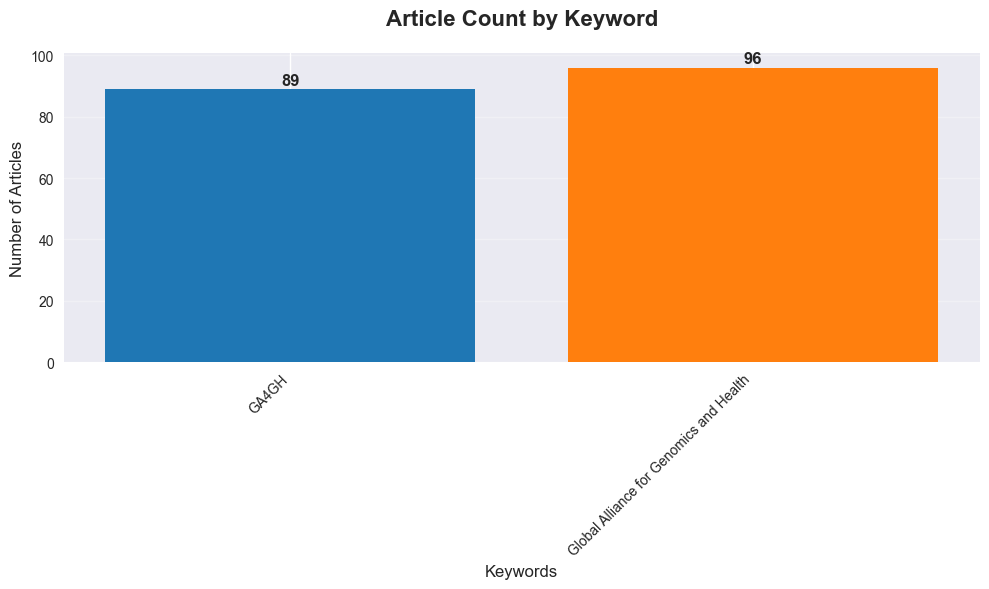

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

keyword_counts = {keyword: len(articles) for keyword, articles in all_articles_data.items()}
bars = ax.bar(keyword_counts.keys(), keyword_counts.values(), color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
           f"{int(height)}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Article Count by Keyword", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Keywords", fontsize=12)
ax.set_ylabel("Number of Articles", fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.2 Publication Timeline Analysis

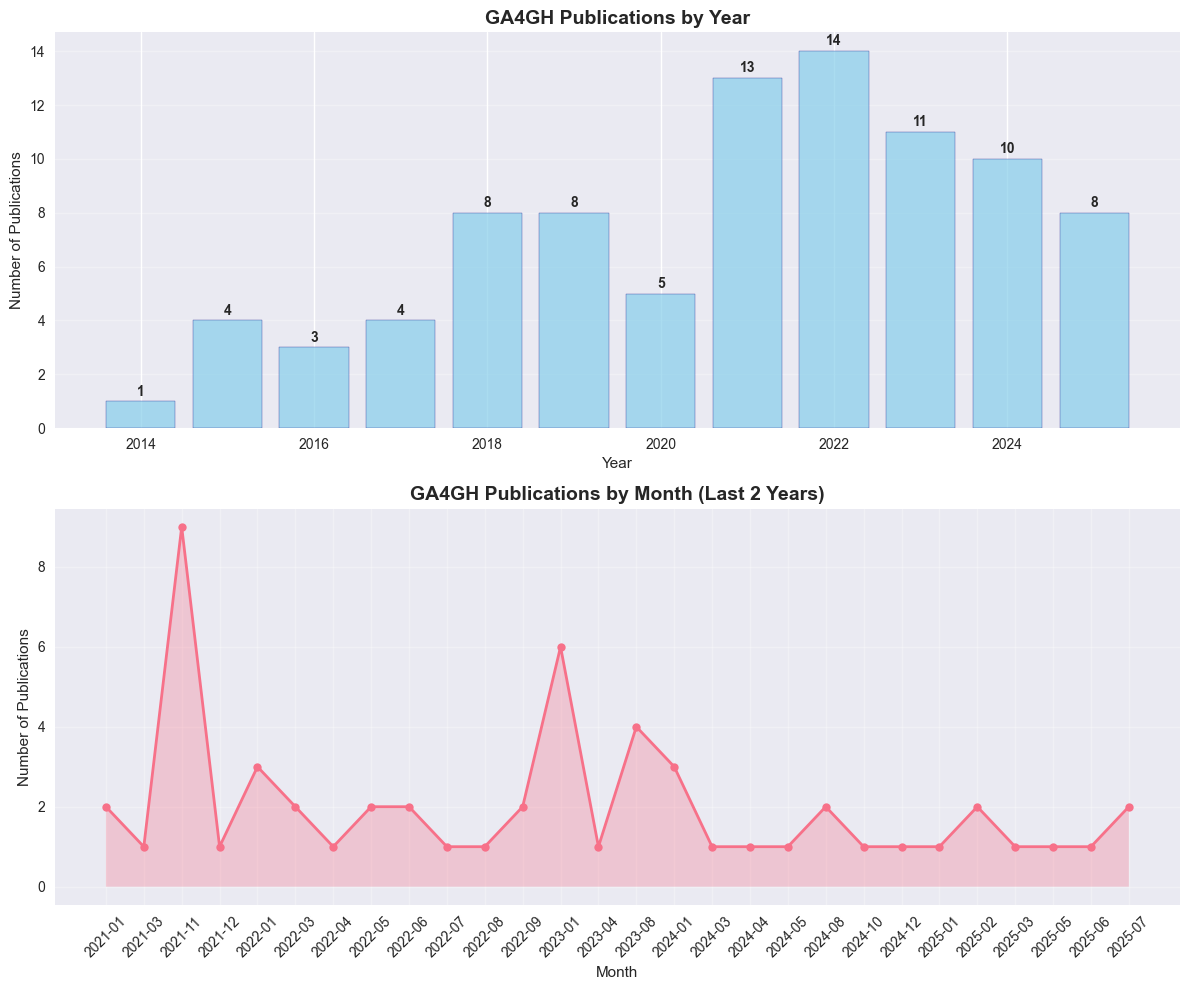

Total publications with dates: 89
Date range: 2014-09-18 to 2025-07-29


In [55]:
def parse_publication_dates(articles):
    """Extract and parse publication dates from articles"""
    dates = []
    for article in articles:
        pub_date = article.get("publish_date")
        if pub_date:
            try:
                # Parse ISO format date
                date_obj = datetime.fromisoformat(pub_date.replace("Z", "+00:00"))
                dates.append(date_obj)
            except:
                continue
    return dates

# Analyze publication timeline for GA4GH
ga4gh_articles = all_articles_data.get("GA4GH", [])
ga4gh_dates = parse_publication_dates(ga4gh_articles)

if ga4gh_dates:
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame({"date": ga4gh_dates})
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.to_period("M")

    # Plot publication timeline
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Publications by year
    yearly_counts = df["year"].value_counts().sort_index()
    ax1.bar(yearly_counts.index, yearly_counts.values, color="skyblue", edgecolor="navy", alpha=0.7)
    ax1.set_title("GA4GH Publications by Year", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Number of Publications")
    ax1.grid(axis="y", alpha=0.3)

    # Add value labels
    for year, count in yearly_counts.items():
        ax1.text(year, count + 0.1, str(count), ha="center", va="bottom", fontweight="bold")

    # Publications by month (last 2 years)
    recent_data = df[df["date"] >= pd.Timestamp.now() - pd.DateOffset(years=5)]
    if not recent_data.empty:
        monthly_counts = recent_data["month"].value_counts().sort_index()

        ax2.plot(range(len(monthly_counts)), monthly_counts.values, marker="o", linewidth=2, markersize=6)
        ax2.fill_between(range(len(monthly_counts)), monthly_counts.values, alpha=0.3)
        ax2.set_title("GA4GH Publications by Month (Last 2 Years)", fontsize=14, fontweight="bold")
        ax2.set_xlabel("Month")
        ax2.set_ylabel("Number of Publications")
        ax2.set_xticks(range(len(monthly_counts)))
        ax2.set_xticklabels([str(period) for period in monthly_counts.index], rotation=45)
        ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, "No recent publication data available", transform=ax2.transAxes,
                ha="center", va="center", fontsize=12)
        ax2.set_title("GA4GH Publications by Month (Last 2 Years)", fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

    print(f"Total publications with dates: {len(ga4gh_dates)}")
    print(f"Date range: {min(ga4gh_dates).strftime('%Y-%m-%d')} to {max(ga4gh_dates).strftime('%Y-%m-%d')}")
else:
    print("No publication dates found for timeline analysis")

### 10.3 Top Journals Analysis

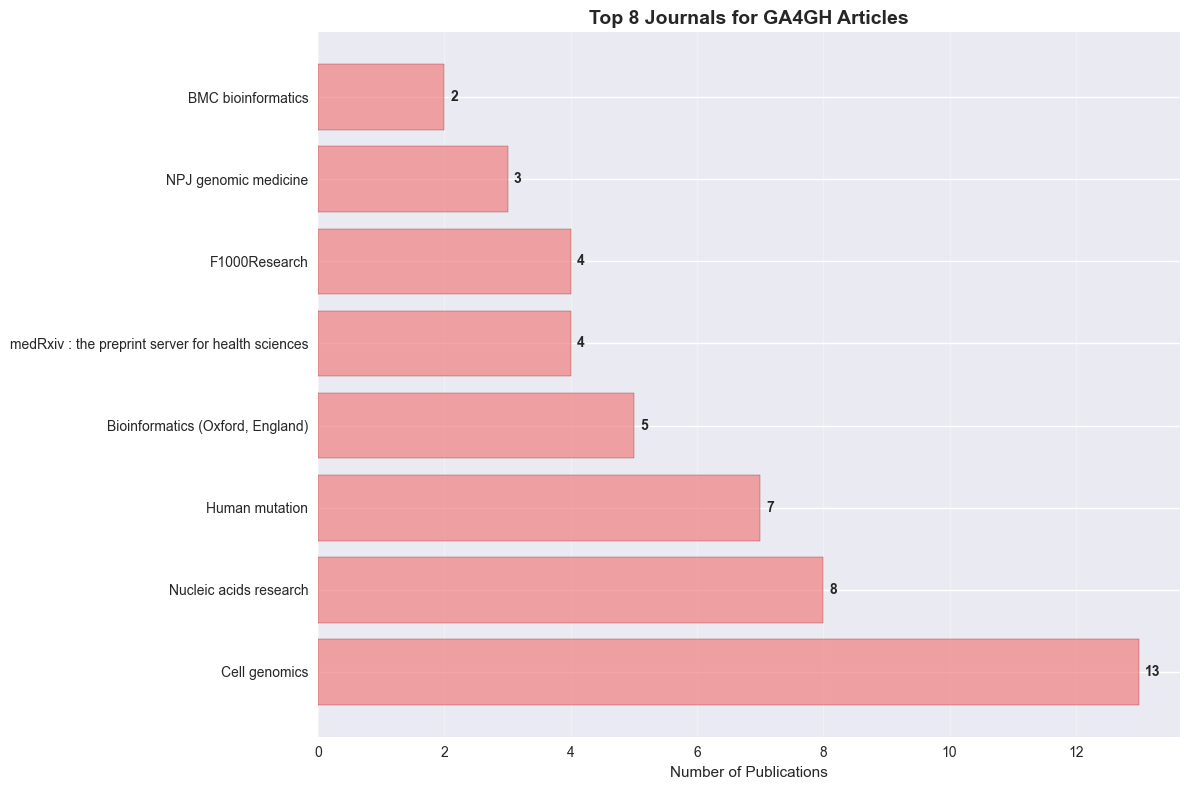

\nTop 8 journals for GA4GH:
  1. Cell genomics: 13 articles
  2. Nucleic acids research: 8 articles
  3. Human mutation: 7 articles
  4. Bioinformatics (Oxford, England): 5 articles
  5. medRxiv : the preprint server for health sciences: 4 articles
  6. F1000Research: 4 articles
  7. NPJ genomic medicine: 3 articles
  8. BMC bioinformatics: 2 articles


In [56]:
def analyze_journals(articles, keyword, top_n=10):
    journals = [article.get("journal", "Unknown") for article in articles if article.get("journal")]

    if not journals:
        print(f"No journal data found for {keyword}")
        return

    journal_counts = Counter(journals)
    top_journals = journal_counts.most_common(top_n)

    # Create horizontal bar chart
    fig, ax = plt.subplots(figsize=(12, 8))

    journals_list, counts_list = zip(*top_journals, strict=False)
    y_pos = np.arange(len(journals_list))

    bars = ax.barh(y_pos, counts_list, color="lightcoral", edgecolor="darkred", alpha=0.7)

    # Add value labels
    for i, (bar, count) in enumerate(zip(bars, counts_list, strict=False)):
        width = bar.get_width()
        ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
               f"{count}", ha="left", va="center", fontweight="bold")

    ax.set_yticks(y_pos)
    ax.set_yticklabels([journal[:50] + "..." if len(journal) > 50 else journal for journal in journals_list])
    ax.set_xlabel("Number of Publications")
    ax.set_title(f"Top {top_n} Journals for {keyword} Articles", fontsize=14, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\\nTop {top_n} journals for {keyword}:")
    for i, (journal, count) in enumerate(top_journals, 1):
        print(f"  {i}. {journal}: {count} articles")

# Analyze journals for GA4GH
if ga4gh_articles:
    analyze_journals(ga4gh_articles, "GA4GH", top_n=8)

### 10.4 Author Analysis

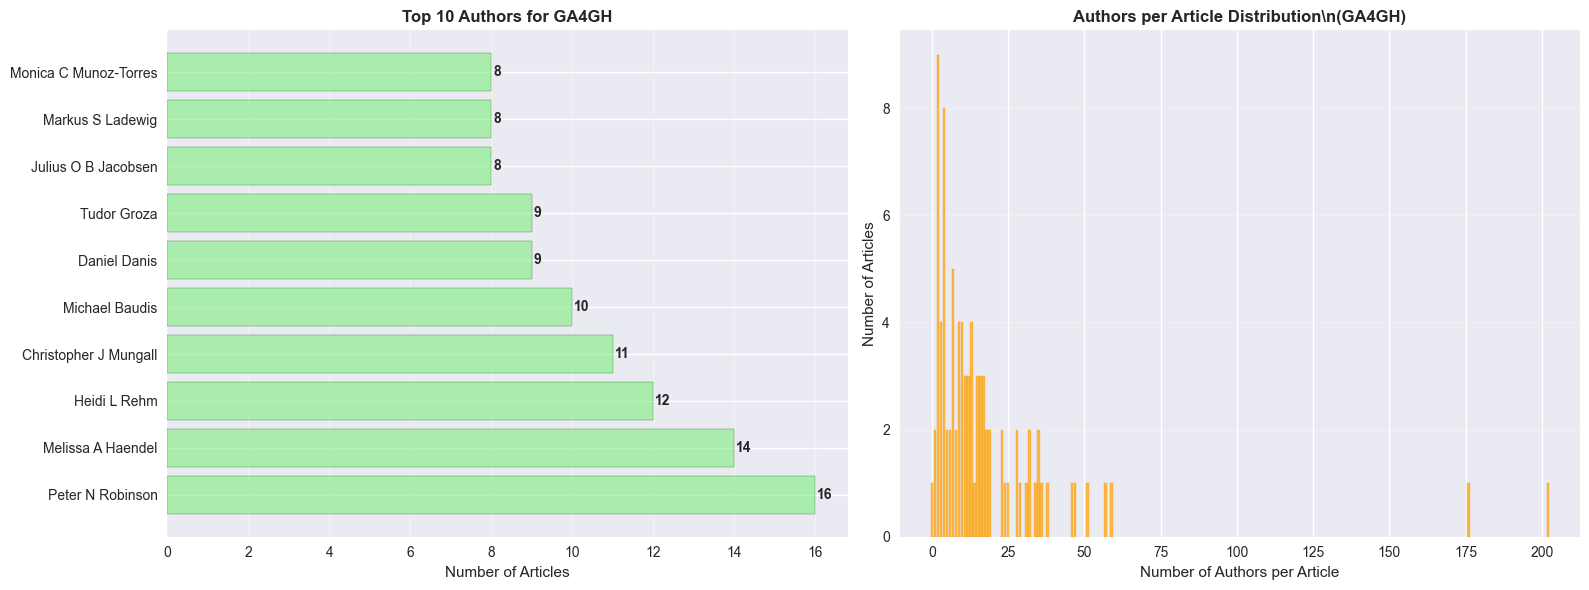

\nAuthor Statistics for GA4GH:
  Total unique authors: 1106
  Average authors per article: 18.62
  Articles analyzed: 89
\nTop 5 most prolific authors:
  1. Peter N Robinson: 16 articles
  2. Melissa A Haendel: 14 articles
  3. Heidi L Rehm: 12 articles
  4. Christopher J Mungall: 11 articles
  5. Michael Baudis: 10 articles


In [57]:
def analyze_authors(articles, keyword):
    """Analyze author data from articles"""
    all_authors = []
    author_article_count = Counter()

    for article in articles:
        authors = article.get("authors", [])
        for author in authors:
            author_name = author.get("name", "Unknown")
            all_authors.append(author_name)
            author_article_count[author_name] += 1

    if not all_authors:
        print(f"No author data found for {keyword}")
        return

    # Get top authors
    top_authors = author_article_count.most_common(10)

    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Author statistics
    total_authors = len(set(all_authors))
    avg_authors_per_article = len(all_authors) / len(articles) if articles else 0

    # Top authors bar chart
    if top_authors:
        authors_list, counts_list = zip(*top_authors, strict=False)
        y_pos = np.arange(len(authors_list))

        bars = ax1.barh(y_pos, counts_list, color="lightgreen", edgecolor="darkgreen", alpha=0.7)

        # Add value labels
        for bar, count in zip(bars, counts_list, strict=False):
            width = bar.get_width()
            ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2,
                   f"{count}", ha="left", va="center", fontweight="bold")

        ax1.set_yticks(y_pos)
        ax1.set_yticklabels([name[:30] + "..." if len(name) > 30 else name for name in authors_list])
        ax1.set_xlabel("Number of Articles")
        ax1.set_title(f"Top 10 Authors for {keyword}", fontsize=12, fontweight="bold")
        ax1.grid(axis="x", alpha=0.3)

    # Authors per article distribution
    authors_per_article = [len(article.get("authors", [])) for article in articles]
    author_count_dist = Counter(authors_per_article)

    if author_count_dist:
        ax2.bar(author_count_dist.keys(), author_count_dist.values(),
               color="orange", edgecolor="darkorange", alpha=0.7)
        ax2.set_xlabel("Number of Authors per Article")
        ax2.set_ylabel("Number of Articles")
        ax2.set_title(f"Authors per Article Distribution\\n({keyword})", fontsize=12, fontweight="bold")
        ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\\nAuthor Statistics for {keyword}:")
    print(f"  Total unique authors: {total_authors}")
    print(f"  Average authors per article: {avg_authors_per_article:.2f}")
    print(f"  Articles analyzed: {len(articles)}")

    if top_authors:
        print("\\nTop 5 most prolific authors:")
        for i, (author, count) in enumerate(top_authors[:5], 1):
            print(f"  {i}. {author}: {count} articles")

# Analyze authors for GA4GH
if ga4gh_articles:
    analyze_authors(ga4gh_articles, "GA4GH")

### 10.5 Comprehensive Dashboard Summary

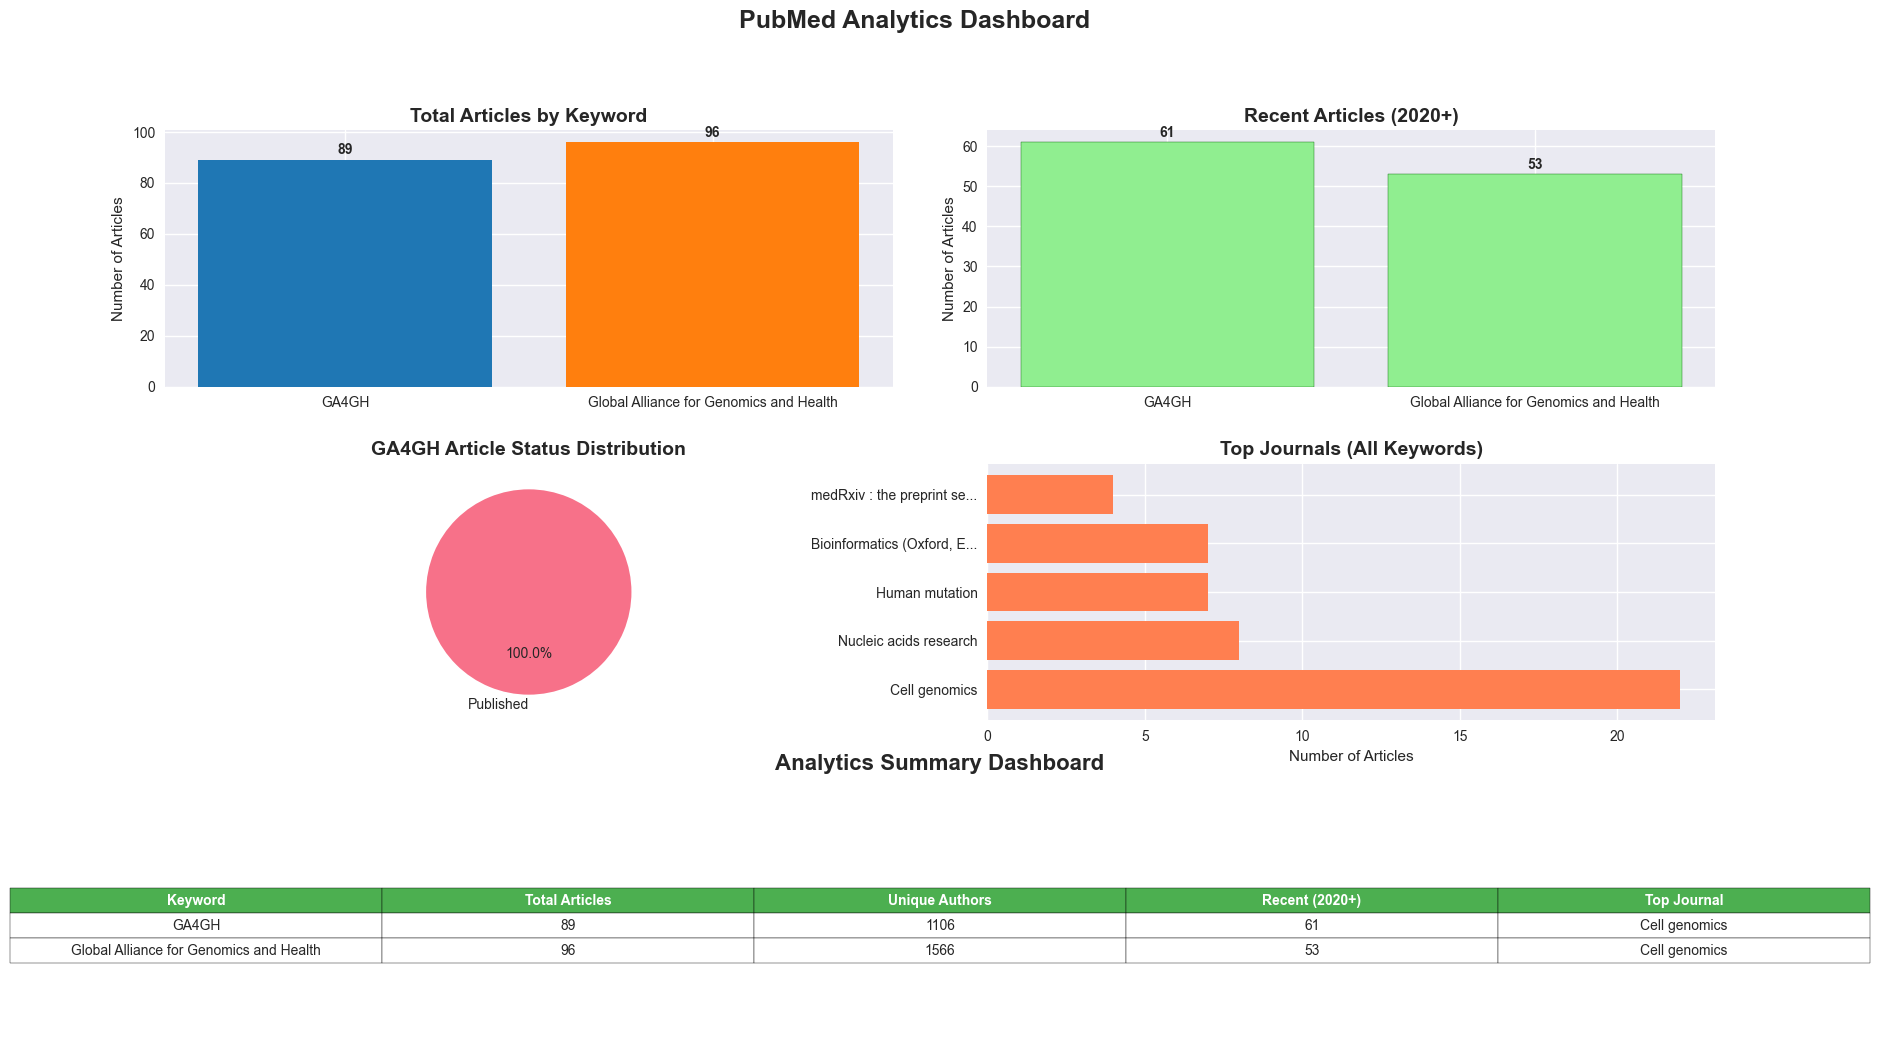

=== ANALYTICS SUMMARY ===
Total articles across all keywords: 185
Total unique authors: 2672
Keywords analyzed: 2
\nGA4GH:
  Articles: 89
  Unique authors: 1106
  Recent (2020+): 61
  Date range: 2014-09-18 to 2025-07-29
\nGlobal Alliance for Genomics and Health:
  Articles: 96
  Unique authors: 1566
  Recent (2020+): 53
  Date range: 2014-01-01 to 2025-07-29


In [58]:
def create_analytics_dashboard():
    dashboard_data = {}
    for keyword, articles in all_articles_data.items():
        if articles:
            total_articles = len(articles)

            statuses = [article.get("status", "Unknown") for article in articles]
            status_counts = Counter(statuses)

            journals = [article.get("journal", "Unknown") for article in articles if article.get("journal")]
            journal_counts = Counter(journals)

            unique_authors = set()
            for article in articles:
                for author in article.get("authors", []):
                    author_name = author.get("name", "Unknown")
                    if author_name != "Unknown":
                        unique_authors.add(author_name)
            total_unique_authors = len(unique_authors)

            dates = parse_publication_dates(articles)

            dashboard_data[keyword] = {
                "total_articles": total_articles,
                "status_counts": status_counts,
                "top_journals": journal_counts.most_common(3),
                "total_authors": total_unique_authors,
                "date_range": (min(dates), max(dates)) if dates else None,
                "recent_articles": len([d for d in dates if d.year >= 2020]) if dates else 0
            }

    fig = plt.figure(figsize=(20, 12))

    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

    # 1. Overall article counts
    ax1 = fig.add_subplot(gs[0, :2])
    keywords_list = list(dashboard_data.keys())
    article_counts = [dashboard_data[k]["total_articles"] for k in keywords_list]

    bars = ax1.bar(keywords_list, article_counts, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
    ax1.set_title("Total Articles by Keyword", fontsize=14, fontweight="bold")
    ax1.set_ylabel("Number of Articles")

    for bar, count in zip(bars, article_counts, strict=False):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
               f"{count}", ha="center", va="bottom", fontweight="bold")

    # 2. Recent articles (2020+)
    ax2 = fig.add_subplot(gs[0, 2:])
    recent_counts = [dashboard_data[k]["recent_articles"] for k in keywords_list]

    bars = ax2.bar(keywords_list, recent_counts, color="lightgreen", edgecolor="darkgreen")
    ax2.set_title("Recent Articles (2020+)", fontsize=14, fontweight="bold")
    ax2.set_ylabel("Number of Articles")

    for bar, count in zip(bars, recent_counts, strict=False):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
               f"{count}", ha="center", va="bottom", fontweight="bold")

    # 3. Status distribution for GA4GH (if available)
    if "GA4GH" in dashboard_data:
        ax3 = fig.add_subplot(gs[1, :2])
        status_data = dashboard_data["GA4GH"]["status_counts"]

        wedges, texts, autotexts = ax3.pie(status_data.values(), labels=status_data.keys(),
                                          autopct="%1.1f%%", startangle=90)
        ax3.set_title("GA4GH Article Status Distribution", fontsize=14, fontweight="bold")

    # 4. Top journals across all keywords
    ax4 = fig.add_subplot(gs[1, 2:])
    all_journals = Counter()
    for data in dashboard_data.values():
        for journal, count in data["top_journals"]:
            all_journals[journal] += count

    top_all_journals = all_journals.most_common(5)
    if top_all_journals:
        journals, counts = zip(*top_all_journals, strict=False)
        y_pos = np.arange(len(journals))

        bars = ax4.barh(y_pos, counts, color="coral")
        ax4.set_yticks(y_pos)
        ax4.set_yticklabels([j[:25] + "..." if len(j) > 25 else j for j in journals])
        ax4.set_title("Top Journals (All Keywords)", fontsize=14, fontweight="bold")
        ax4.set_xlabel("Number of Articles")

    # 5. Summary statistics table
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis("tight")
    ax5.axis("off")

    # Create summary table
    table_data = []
    headers = ["Keyword", "Total Articles", "Unique Authors", "Recent (2020+)", "Top Journal"]

    for keyword, data in dashboard_data.items():
        top_journal = data["top_journals"][0][0] if data["top_journals"] else "N/A"
        if len(top_journal) > 30:
            top_journal = top_journal[:30] + "..."

        table_data.append([
            keyword,
            data["total_articles"],
            data["total_authors"],
            data["recent_articles"],
            top_journal
        ])

    table = ax5.table(cellText=table_data, colLabels=headers,
                     cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    # Style the table
    for i in range(len(headers)):
        table[(0, i)].set_facecolor("#4CAF50")
        table[(0, i)].set_text_props(weight="bold", color="white")

    ax5.set_title("Analytics Summary Dashboard", fontsize=16, fontweight="bold", pad=20)

    plt.suptitle("PubMed Analytics Dashboard", fontsize=18, fontweight="bold", y=0.98)
    plt.show()

    # Print summary
    print("=== ANALYTICS SUMMARY ===")
    total_all_articles = sum(data["total_articles"] for data in dashboard_data.values())
    total_all_authors = sum(data["total_authors"] for data in dashboard_data.values())

    print(f"Total articles across all keywords: {total_all_articles}")
    print(f"Total unique authors: {total_all_authors}")
    print(f"Keywords analyzed: {len(dashboard_data)}")

    for keyword, data in dashboard_data.items():
        print(f"\\n{keyword}:")
        print(f"  Articles: {data['total_articles']}")
        print(f"  Unique authors: {data['total_authors']}")
        print(f"  Recent (2020+): {data['recent_articles']}")
        if data["date_range"]:
            start_date, end_date = data["date_range"]
            print(f"  Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# Create the dashboard
create_analytics_dashboard()